# Kalman Filter Simulation
Tests `KalmanBBBSignal` on `data.csv` by replaying prices one tick at a time — no future data is ever used.

Run cells top to bottom. Re-run individual cells to experiment without reloading everything.

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Make sure kalman_signal.py (in the same folder) is importable
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from kalman_signal import KalmanBBBSignal

## Config
Change these and re-run the cells below to experiment.

In [ ]:
DATA_FILE    = "../Competition/Alpha Testing V2/data.csv"
STOCK        = "BBB"   # AAA, BBB, CCC, DDD, ETF

# Ticks fed to the filter before streaming starts.
# 0 = true cold start (filter has seen nothing)
WARMUP_TICKS = 0

# Kalman noise — vel_noise high means the filter reacts fast to trend changes
POS_NOISE    = 0.01
VEL_NOISE    = 5.0
OBS_NOISE    = 1.0

## Load data

In [3]:
df = pd.read_csv(DATA_FILE)
print(f"Loaded {len(df)} rows")
df.head()

Loaded 23460 rows


,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


## Run simulation
Prices are fed into the filter one tick at a time. The filter never sees tick `i+1` when processing tick `i`.

In [ ]:
prices = df[STOCK].values

# Optional warmup — mimics fetching get_history() at Rotman startup
warmup = prices[:WARMUP_TICKS].tolist() if WARMUP_TICKS > 0 else None

kf = KalmanBBBSignal(
    warmup_prices=warmup,
    pos_noise=POS_NOISE,
    vel_noise=VEL_NOISE,
    obs_noise=OBS_NOISE,
)

records = []

# Warmup ticks — replay through a cold filter just to get per-tick values for plotting
if WARMUP_TICKS > 0:
    tmp_kf = KalmanBBBSignal(pos_noise=POS_NOISE, vel_noise=VEL_NOISE,
                              obs_noise=OBS_NOISE)
    for i in range(WARMUP_TICKS):
        tmp_kf.update(prices[i])
        records.append({"tick": i, "price": prices[i],
                         "position": tmp_kf.position, "velocity": tmp_kf.velocity,
                         "phase": "warmup"})

# Live streaming — one tick at a time, no future data
for i in range(WARMUP_TICKS, len(prices)):
    kf.update(prices[i])
    records.append({"tick": i, "price": prices[i],
                     "position": kf.position, "velocity": kf.velocity,
                     "phase": "live"})

results = pd.DataFrame(records)

# Normalise: divide every velocity by the single highest absolute value
max_abs_vel = results["velocity"].abs().max()
results["signal"] = (results["velocity"] / max_abs_vel).clip(-1, 1) if max_abs_vel > 0 else 0.0

print(f"Done — {len(results)} ticks processed")
results.head(10)

## Price vs Kalman position estimate

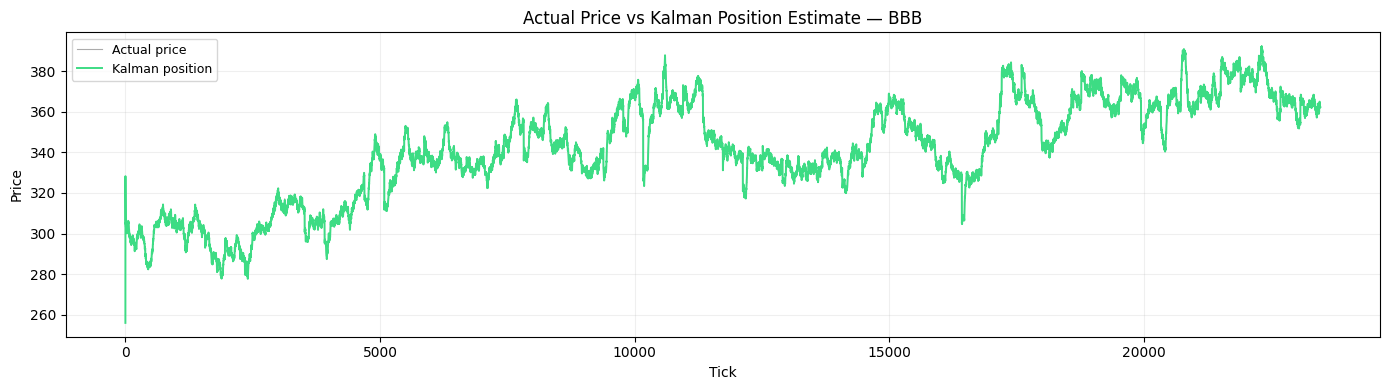

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(results["tick"], results["price"],    color="#888888", linewidth=0.8, label="Actual price", alpha=0.7)
ax.plot(results["tick"], results["position"], color="#3ddc84", linewidth=1.4, label="Kalman position")

if WARMUP_TICKS > 0:
    ax.axvspan(0, WARMUP_TICKS - 1, color="#ffc44d", alpha=0.08, label="Warmup")

ax.set_title(f"Actual Price vs Kalman Position Estimate — {STOCK}")
ax.set_xlabel("Tick")
ax.set_ylabel("Price")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Position coloured by velocity

## All stocks — position coloured by velocity

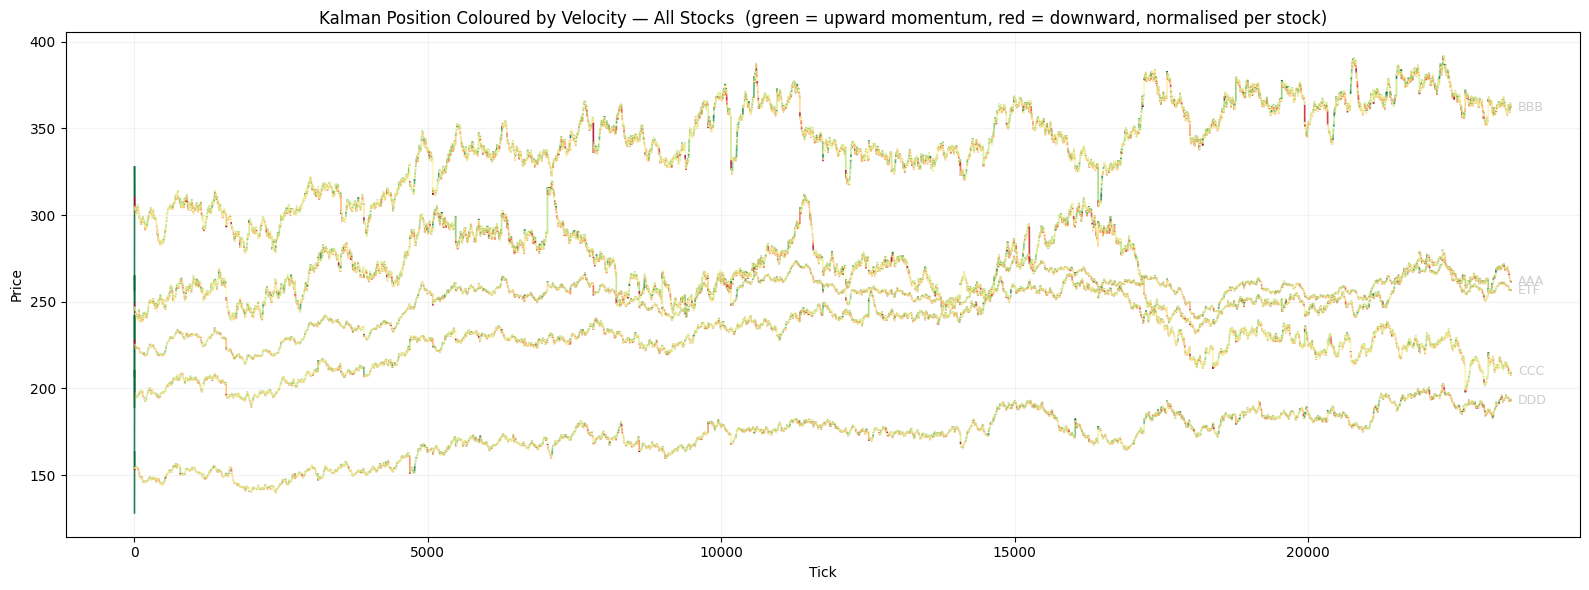

In [27]:
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm

ALL_STOCKS = ["AAA", "BBB", "CCC", "DDD", "ETF"]

fig, ax = plt.subplots(figsize=(16, 6))

for stock in ALL_STOCKS:
    stock_prices = df[stock].values
    kf_s = KalmanBBBSignal(pos_noise=POS_NOISE, vel_noise=VEL_NOISE, obs_noise=OBS_NOISE)

    pos_list, vel_list = [], []
    for price in stock_prices:
        kf_s.update(price)
        pos_list.append(kf_s.position)
        vel_list.append(kf_s.velocity)

    ticks   = np.arange(len(stock_prices))
    pos_arr = np.array(pos_list)
    vel_arr = np.array(vel_list)

    points   = np.column_stack([ticks, pos_arr]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    seg_vel  = vel_arr[:-1]

    # Normalise colour scale per stock to 99th-percentile abs velocity
    # (avoids the cold-start spike washing out all other colours)
    vmax = np.percentile(np.abs(seg_vel), 99) or 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    lc = LineCollection(segments, cmap="RdYlGn", norm=norm, linewidth=1.2, alpha=0.85)
    lc.set_array(seg_vel)
    ax.add_collection(lc)

    ax.annotate(stock, xy=(ticks[-1], pos_arr[-1]),
                xytext=(ticks[-1] + 120, pos_arr[-1]),
                fontsize=9, va="center", color="#cccccc")

ax.autoscale()
ax.set_title("Kalman Position Coloured by Velocity — All Stocks  "
             "(green = upward momentum, red = downward, normalised per stock)")
ax.set_xlabel("Tick")
ax.set_ylabel("Price")
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

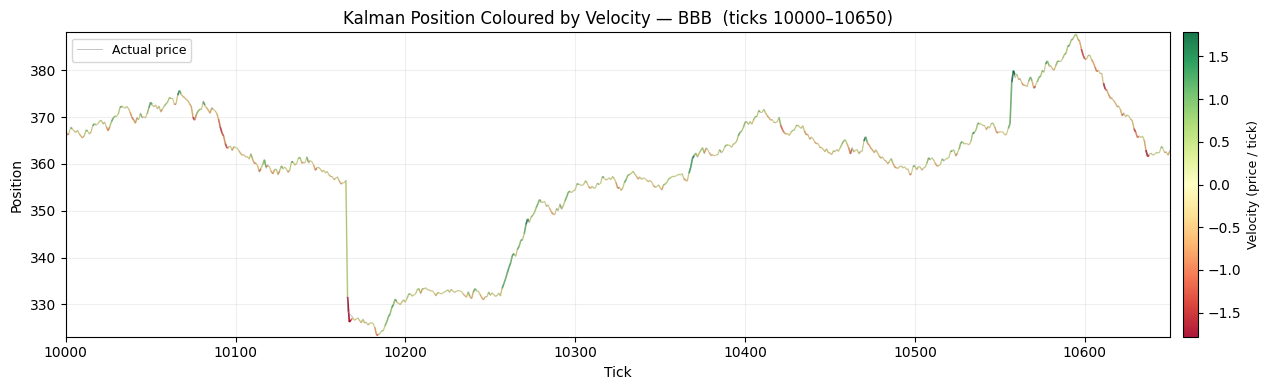

In [6]:
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm

def plot_position_by_velocity(left, right):
    window = results[(results["tick"] >= left) & (results["tick"] <= right)]

    ticks = window["tick"].values
    pos   = window["position"].values
    vel   = window["velocity"].values

    points   = np.column_stack([ticks, pos]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    seg_vel  = vel[:-1]

    vmax = np.percentile(np.abs(seg_vel), 99) or 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    lc = LineCollection(segments, cmap="RdYlGn", norm=norm, linewidth=1.2, alpha=0.9)
    lc.set_array(seg_vel)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.add_collection(lc)
    ax.plot(ticks, window["price"].values, color="#888888", linewidth=0.7,
            alpha=0.5, label="Actual price")

    cb = fig.colorbar(lc, ax=ax, pad=0.01)
    cb.set_label("Velocity (price / tick)", fontsize=9)

    if WARMUP_TICKS > 0:
        ax.axvspan(max(left, 0), min(WARMUP_TICKS - 1, right),
                   color="#ffc44d", alpha=0.08, label="Warmup")

    ax.set_xlim(ticks[0], ticks[-1])
    ax.set_ylim(pos.min() * 0.999, pos.max() * 1.001)
    ax.set_title(f"Kalman Position Coloured by Velocity — {STOCK}  (ticks {left}–{right})")
    ax.set_xlabel("Tick")
    ax.set_ylabel("Position")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_position_by_velocity(10000, 10650)

## Velocity estimate

c:\Users\Ruben\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


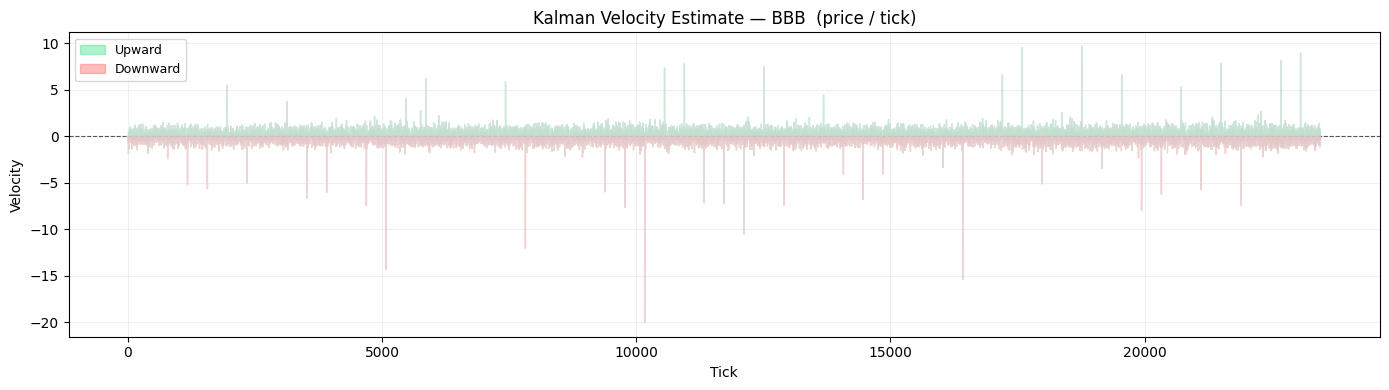

In [22]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.axhline(0, color="#555555", linewidth=0.8, linestyle="--")
ax.fill_between(results["tick"][5:], results["velocity"][5:], 0,
                where=(results["velocity"][5:] >= 0), color="#3ddc84", alpha=0.4, label="Upward")
ax.fill_between(results["tick"][5:], results["velocity"][5:], 0,
                where=(results["velocity"][5:] < 0),  color="#ff5c5c", alpha=0.4, label="Downward")
ax.plot(results["tick"][5:], results["velocity"][5:], color="#e0e0e0", linewidth=0.8, alpha=0.8)

if WARMUP_TICKS > 0:
    ax.axvspan(0, WARMUP_TICKS - 1, color="#ffc44d", alpha=0.08, label="Warmup")

ax.set_title(f"Kalman Velocity Estimate — {STOCK}  (price / tick)")
ax.set_xlabel("Tick")
ax.set_ylabel("Velocity")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Normalised signal  `[−1, 1]`

C:\Users\Ruben\AppData\Local\Temp\ipykernel_22488\3949647137.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


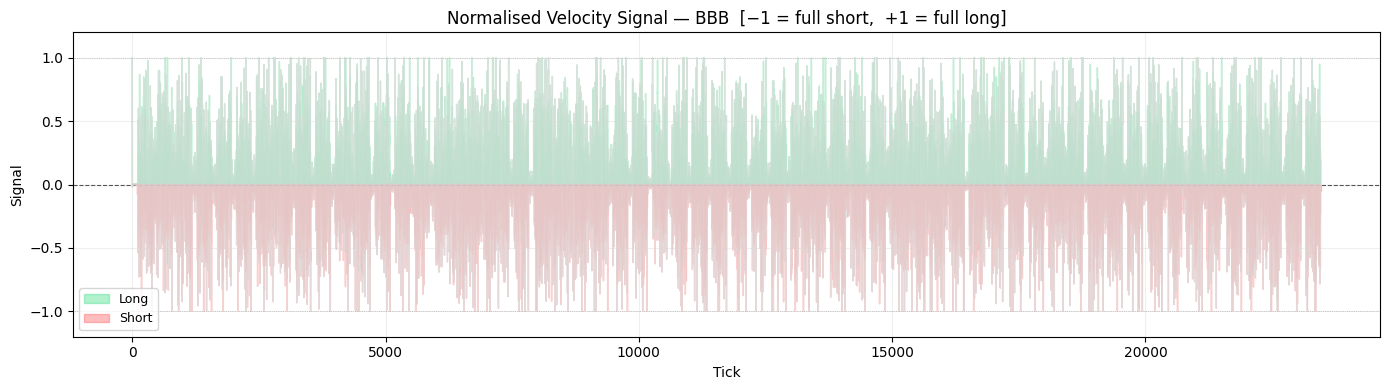

In [23]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.axhline(0,  color="#555555", linewidth=0.8, linestyle="--")
ax.axhline( 1, color="#555555", linewidth=0.5, linestyle=":", alpha=0.5)
ax.axhline(-1, color="#555555", linewidth=0.5, linestyle=":", alpha=0.5)
ax.fill_between(results["tick"], results["signal"], 0,
                where=(results["signal"] >= 0), color="#3ddc84", alpha=0.4, label="Long")
ax.fill_between(results["tick"], results["signal"], 0,
                where=(results["signal"] < 0),  color="#ff5c5c", alpha=0.4, label="Short")
ax.plot(results["tick"], results["signal"], color="#e0e0e0", linewidth=0.8, alpha=0.8)

if WARMUP_TICKS > 0:
    ax.axvspan(0, WARMUP_TICKS - 1, color="#ffc44d", alpha=0.08, label="Warmup")

ax.set_ylim(-1.2, 1.2)
ax.set_title(f"Normalised Velocity Signal — {STOCK}  [−1 = full short,  +1 = full long]")
ax.set_xlabel("Tick")
ax.set_ylabel("Signal")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Stats

In [16]:
live = results[results["phase"] == "live"]

print(f"Stock          : {STOCK}")
print(f"Total ticks    : {len(live)}")
print(f"Warmup ticks   : {WARMUP_TICKS}")
print(f"vel_noise      : {VEL_NOISE}   pos_noise: {POS_NOISE}")
print()
print("Velocity (live phase):")
print(live["velocity"].describe().to_string())
print()
print("Signal (live phase):")
print(f"  % long  : {(live['signal'] > 0).mean()*100:.1f}%")
print(f"  % short : {(live['signal'] < 0).mean()*100:.1f}%")
print(f"  % flat  : {(live['signal'] == 0).mean()*100:.1f}%")

Stock          : BBB
Total ticks    : 23460
Warmup ticks   : 0
vel_noise      : 5.0   pos_noise: 0.01

Velocity (live phase):
count    23460.000000
mean         0.018069
std          1.929842
min        -20.046334
25%         -0.363667
50%          0.002745
75%          0.375873
max        255.058140

Signal (live phase):
  % long  : 50.2%
  % short : 49.8%
  % flat  : 0.0%


## Experiment — zoom into a specific tick range

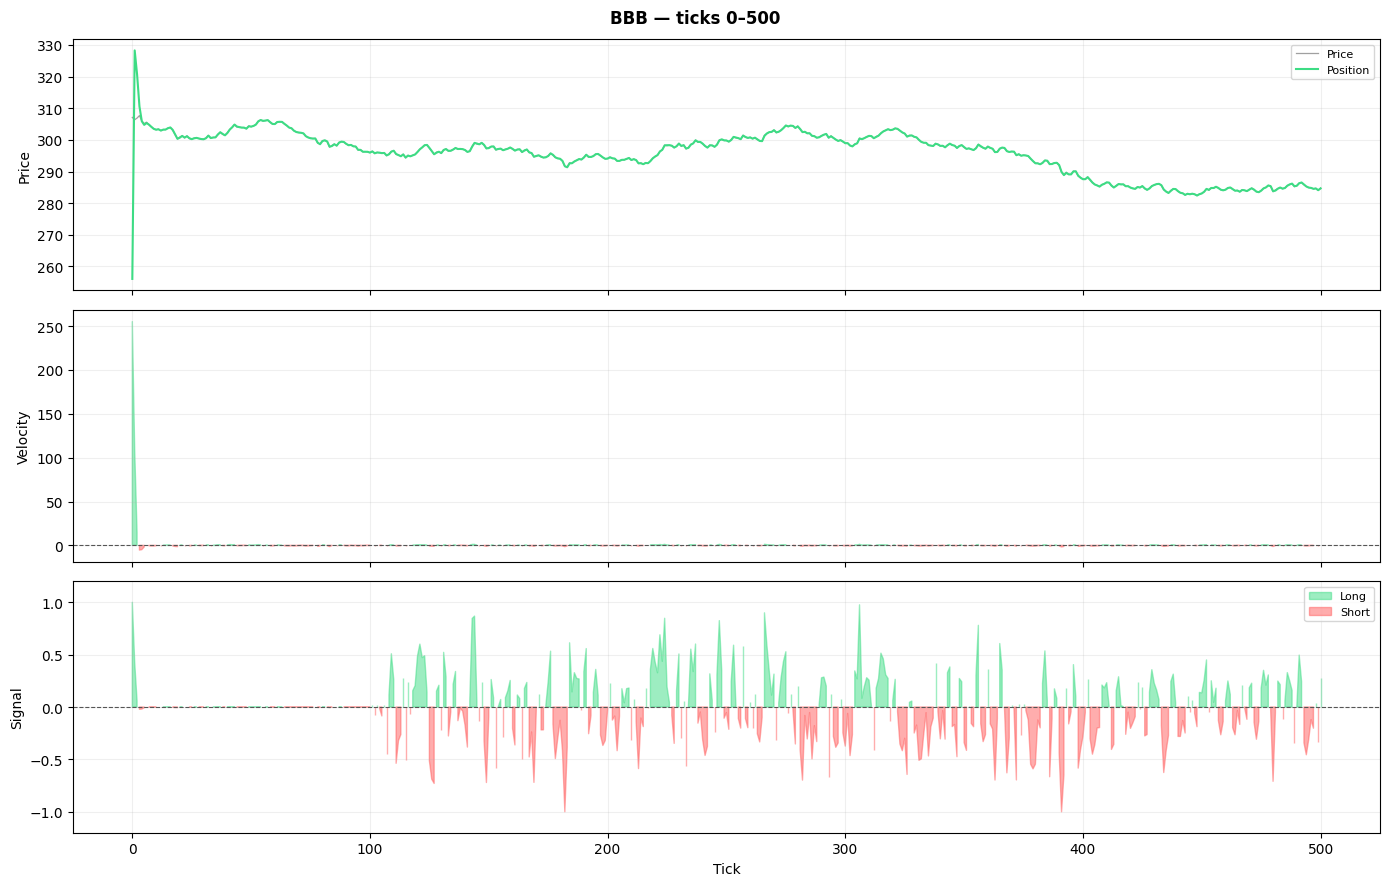

In [17]:
TICK_START = 0
TICK_END   = 500   # change this to zoom in

window = results[(results["tick"] >= TICK_START) & (results["tick"] <= TICK_END)]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f"{STOCK} — ticks {TICK_START}–{TICK_END}", fontsize=12, fontweight="bold")

axes[0].plot(window["tick"], window["price"],    color="#888888", linewidth=0.9, label="Price", alpha=0.8)
axes[0].plot(window["tick"], window["position"], color="#3ddc84", linewidth=1.5, label="Position")
axes[0].set_ylabel("Price"); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.2)

axes[1].axhline(0, color="#555", linewidth=0.8, linestyle="--")
axes[1].fill_between(window["tick"], window["velocity"], 0,
                     where=(window["velocity"] >= 0), color="#3ddc84", alpha=0.5)
axes[1].fill_between(window["tick"], window["velocity"], 0,
                     where=(window["velocity"] < 0),  color="#ff5c5c", alpha=0.5)
axes[1].set_ylabel("Velocity"); axes[1].grid(True, alpha=0.2)

axes[2].axhline(0, color="#555", linewidth=0.8, linestyle="--")
axes[2].fill_between(window["tick"], window["signal"], 0,
                     where=(window["signal"] >= 0), color="#3ddc84", alpha=0.5, label="Long")
axes[2].fill_between(window["tick"], window["signal"], 0,
                     where=(window["signal"] < 0),  color="#ff5c5c", alpha=0.5, label="Short")
axes[2].set_ylim(-1.2, 1.2)
axes[2].set_ylabel("Signal"); axes[2].set_xlabel("Tick")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Backtest — Kalman signal as alpha

In [24]:
BT_STOCK = "ETF"   # stock to trade — AAA, BBB, CCC, DDD, ETF (signal always comes from STOCK above)

In [25]:
from simulator import simulate, print_summary

bt = simulate(
    alphas     = results["signal"].values,
    prices     = df.loc[results["tick"], BT_STOCK].values,
    ind_prices = df.loc[results["tick"], "IND"].values,
    capital    = 10_000,
)

print_summary(bt)

  Total P&L      : $      302.90
  Sharpe ratio   :      -1.0991
  Win rate       :        49.2%
  Max drawdown   : $     -964.09
  Mean return/tk :     0.000001
  Std  return/tk :     0.001115


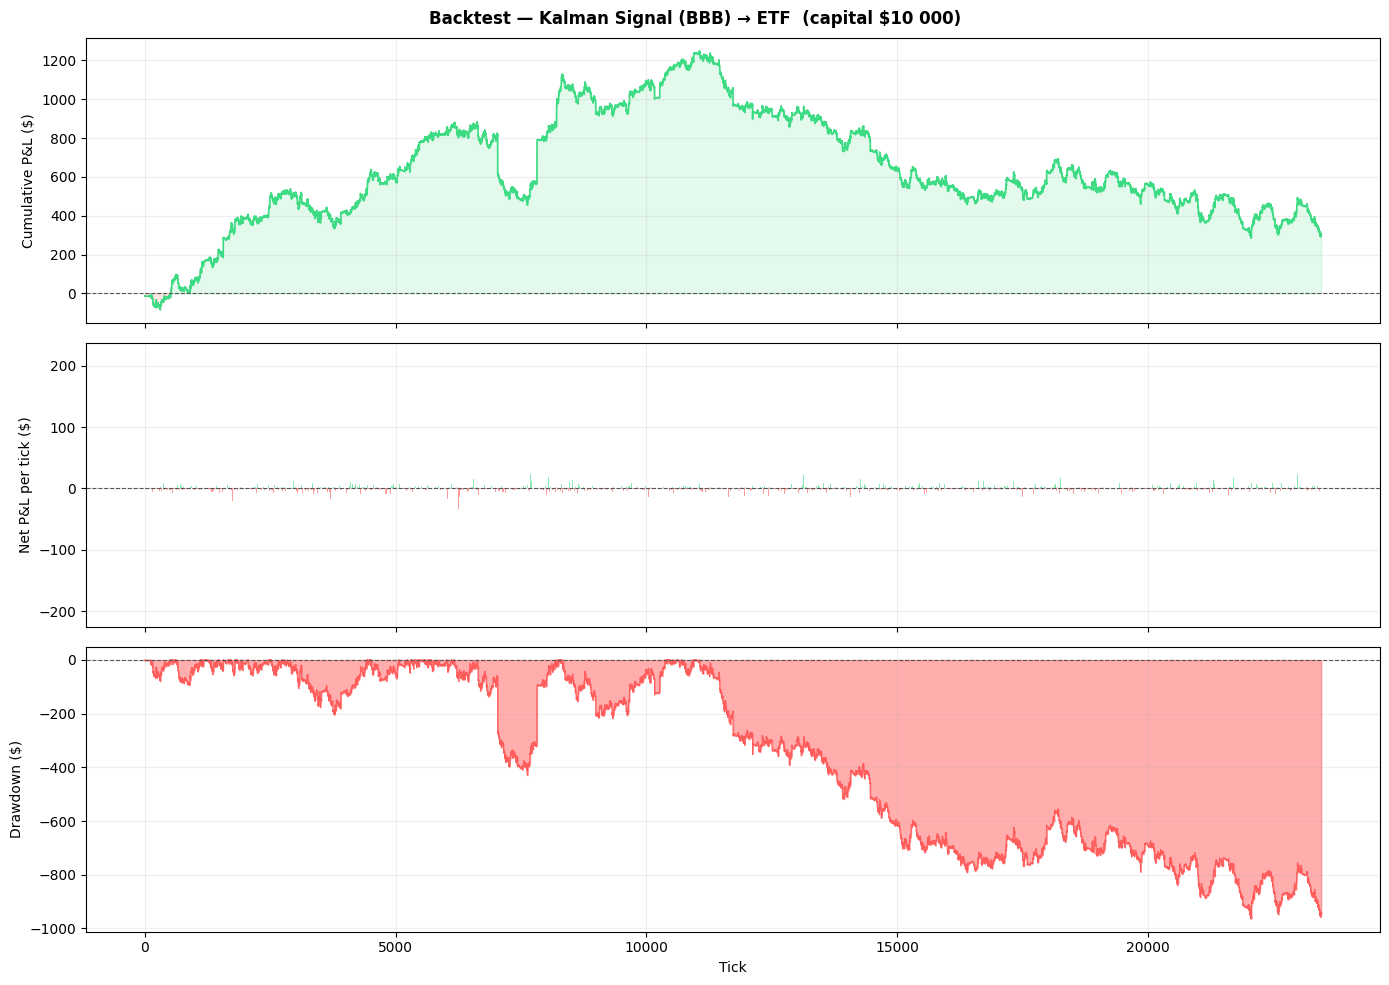

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"Backtest — Kalman Signal ({STOCK}) → {BT_STOCK}  (capital $10 000)", fontsize=12, fontweight="bold")

# ── Cumulative P&L ────────────────────────────────────────────────────────────
axes[0].plot(bt["cumulative_pnl"].index, bt["cumulative_pnl"].values,
             color="#3ddc84", linewidth=1.2)
axes[0].axhline(0, color="#555", linewidth=0.8, linestyle="--")
axes[0].fill_between(bt["cumulative_pnl"].index, bt["cumulative_pnl"].values, 0,
                     where=(bt["cumulative_pnl"].values >= 0), color="#3ddc84", alpha=0.15)
axes[0].fill_between(bt["cumulative_pnl"].index, bt["cumulative_pnl"].values, 0,
                     where=(bt["cumulative_pnl"].values < 0),  color="#ff5c5c", alpha=0.15)
axes[0].set_ylabel("Cumulative P&L ($)")
axes[0].grid(True, alpha=0.2)

# ── Per-tick P&L (skip first 5 — cold-start transient) ───────────────────────
net_trimmed = bt["net_pnl"].iloc[5:]
axes[1].bar(net_trimmed.index, net_trimmed.values, width=1,
            color=np.where(net_trimmed.values >= 0, "#3ddc84", "#ff5c5c"),
            alpha=0.6)
axes[1].axhline(0, color="#555", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Net P&L per tick ($)")
axes[1].grid(True, alpha=0.2)

# ── Drawdown ──────────────────────────────────────────────────────────────────
cum = bt["cumulative_pnl"].values
hwm = np.maximum.accumulate(cum)
dd  = cum - hwm
axes[2].fill_between(bt["cumulative_pnl"].index, dd, 0, color="#ff5c5c", alpha=0.5)
axes[2].plot(bt["cumulative_pnl"].index, dd, color="#ff5c5c", linewidth=0.8)
axes[2].axhline(0, color="#555", linewidth=0.8, linestyle="--")
axes[2].set_ylabel("Drawdown ($)")
axes[2].set_xlabel("Tick")
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Backtest — position diff as velocity

  Total P&L      : $       12.83
  Sharpe ratio   :      -1.4282
  Win rate       :        49.2%
  Max drawdown   : $      -23.16
  Mean return/tk :     0.000000
  Std  return/tk :     0.000990


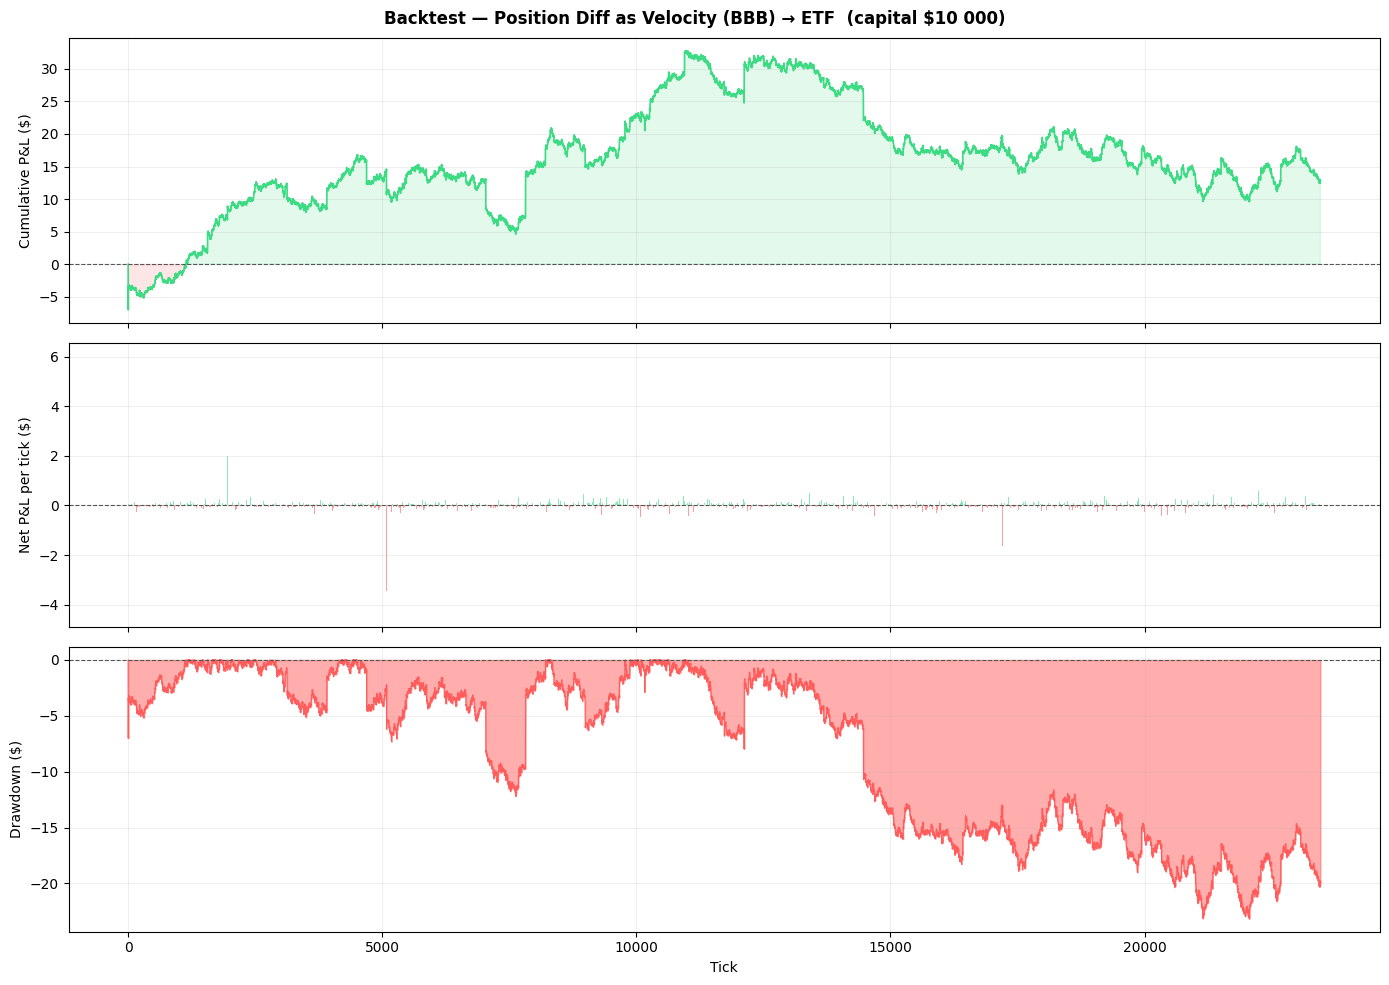

In [21]:
pos_series   = results["position"]
pos_diff     = pos_series.diff()                     # position[t] - position[t-1]
pos_diff.iloc[0] = 0.0                               # first tick has no predecessor

# Normalise by the all-time max absolute value seen so far
expanding_max = pos_diff.abs().expanding(min_periods=1).max()
diff_signal   = (pos_diff / expanding_max.replace(0, np.nan)).fillna(0).clip(-1, 1)

bt_diff = simulate(
    alphas     = diff_signal.values,
    prices     = df.loc[results["tick"], BT_STOCK].values,
    ind_prices = df.loc[results["tick"], "IND"].values,
    capital    = 10_000,
)

print_summary(bt_diff)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"Backtest — Position Diff as Velocity ({STOCK}) → {BT_STOCK}  (capital $10 000)",
             fontsize=12, fontweight="bold")

axes[0].plot(bt_diff["cumulative_pnl"].index, bt_diff["cumulative_pnl"].values,
             color="#3ddc84", linewidth=1.2)
axes[0].axhline(0, color="#555", linewidth=0.8, linestyle="--")
axes[0].fill_between(bt_diff["cumulative_pnl"].index, bt_diff["cumulative_pnl"].values, 0,
                     where=(bt_diff["cumulative_pnl"].values >= 0), color="#3ddc84", alpha=0.15)
axes[0].fill_between(bt_diff["cumulative_pnl"].index, bt_diff["cumulative_pnl"].values, 0,
                     where=(bt_diff["cumulative_pnl"].values < 0),  color="#ff5c5c", alpha=0.15)
axes[0].set_ylabel("Cumulative P&L ($)")
axes[0].grid(True, alpha=0.2)

net_trimmed = bt_diff["net_pnl"].iloc[5:]
axes[1].bar(net_trimmed.index, net_trimmed.values, width=1,
            color=np.where(net_trimmed.values >= 0, "#3ddc84", "#ff5c5c"),
            alpha=0.6)
axes[1].axhline(0, color="#555", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Net P&L per tick ($)")
axes[1].grid(True, alpha=0.2)

cum = bt_diff["cumulative_pnl"].values
hwm = np.maximum.accumulate(cum)
dd  = cum - hwm
axes[2].fill_between(bt_diff["cumulative_pnl"].index, dd, 0, color="#ff5c5c", alpha=0.5)
axes[2].plot(bt_diff["cumulative_pnl"].index, dd, color="#ff5c5c", linewidth=0.8)
axes[2].axhline(0, color="#555", linewidth=0.8, linestyle="--")
axes[2].set_ylabel("Drawdown ($)")
axes[2].set_xlabel("Tick")
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()